## Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import re
import string

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier

# Evaluation
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Upload Dataset

We upload the dataset file (CSV) from local system into Google Colab.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset (1).csv


## Check Uploaded File Name

We verify the exact file name to avoid errors while loading.

In [ ]:
import os
os.listdir()

['.config', 'IMDB Dataset.csv', 'IMDB Dataset (1).csv', 'sample_data']

## Load Dataset

We load the dataset and check its structure.

In [ ]:
df = pd.read_csv('IMDB Dataset.csv')

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


##  Dataset Description

The dataset used is the IMDb Movie Reviews dataset.

- Total Samples: 50,000
- Sentiment Classes: Positive and Negative
- Balanced dataset (25,000 each)

This dataset is widely used for sentiment analysis tasks.

## Dataset Information

This shows column names, data types, and non-null values.

In [ ]:
df = pd.read_csv('IMDB Dataset.csv')

# Make all column names lowercase
df.columns = df.columns.str.lower()

# Rename your text column to 'text' (change 'review' if needed)
df.rename(columns={'review': 'text'}, inplace=True)

# Check
df.head()

,text,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   text       50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [ ]:
print(df.columns)

Index(['text', 'sentiment'], dtype='object')


## Data Understanding

- Checking dataset shape
- Checking null values
- Class distribution

In [ ]:
print("Shape:", df.shape)

print("\nNull Values:\n", df[['text','sentiment']].isnull().sum())

print("\nClass Distribution:\n", df['sentiment'].value_counts())

Shape: (50000, 2)

Null Values:
 text         0
sentiment    0
dtype: int64

Class Distribution:
 sentiment
positive    25000
negative    25000
Name: count, dtype: int64


## Sentiment Distribution

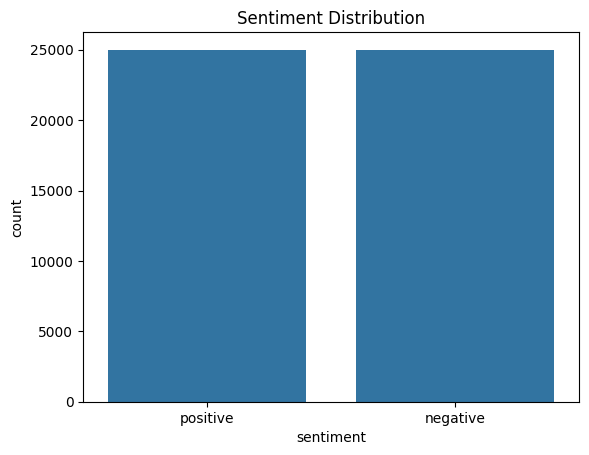

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='sentiment', data=df)
plt.title("Sentiment Distribution")
plt.show()

## NLP Preprocessing

Steps:
- Lowercasing
- Removing punctuation
- Removing stopwords
- Tokenization
- Stemming
- Removing special characters

In [ ]:
def preprocess_text(text):
    if pd.isnull(text):
        return ""

    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    words = text.split()
    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

In [ ]:
# Sample for speed
df = df.sample(10000, random_state=42)

# Apply preprocessing
df['clean_text'] = df['text'].apply(preprocess_text)

## Optimization Applied

Due to large dataset size, preprocessing was computationally expensive.

To improve execution speed, a subset of 10,000 samples was used.

This ensures efficient processing while maintaining model performance.

In [ ]:
df[['text', 'clean_text']].head()

,text,clean_text
0,One of the other reviewers has mentioned that ...,one review mention watch oz episod youll hook ...
1,A wonderful little production. <br /><br />The...,wonder littl product br br film techniqu unass...
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...
3,Basically there's a family where a little boy ...,basic there famili littl boy jake think there ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei love time money visual stun film...


## Preprocessing Completed

A new column `clean_text` is created after applying NLP preprocessing techniques like:
- Lowercasing
- Stopword removal
- Stemming

This cleaned text will be used for feature extraction.

## Feature Engineering - Bag of Words

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

bow = CountVectorizer(max_features=5000)

X_bow = bow.fit_transform(df['clean_text']).toarray()
y = df['sentiment']

## Feature Engineering - TF-IDF

In [ ]:
tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(df['clean_text']).toarray()

## Train-Test Split

In [ ]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42)

X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

## Model Evaluation Function

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
    print("-"*50)

## Logistic Regression

In [ ]:
lr = LogisticRegression()
lr.fit(X_train_tfidf, y_train)

evaluate_model(lr, X_test_tfidf, y_test)

Accuracy: 0.8755
Precision: 0.876869441417126
Recall: 0.8755
F1 Score: 0.8754209993569527
--------------------------------------------------


## Naive Bayes

In [ ]:
nb = MultinomialNB()
nb.fit(X_train_bow, y_train)

evaluate_model(nb, X_test_bow, y_test)

Accuracy: 0.841
Precision: 0.8410876472495407
Recall: 0.841
F1 Score: 0.8409756659674646
--------------------------------------------------


## Decision Tree

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train_tfidf, y_train)

evaluate_model(dt, X_test_tfidf, y_test)

Accuracy: 0.714
Precision: 0.7140181864754098
Recall: 0.714
F1 Score: 0.7139633826259522
--------------------------------------------------


## Random Forest (Additional Model)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_tfidf, y_train)

evaluate_model(rf, X_test_tfidf, y_test)

Accuracy: 0.832
Precision: 0.8320106881710108
Recall: 0.832
F1 Score: 0.8320020160725786
--------------------------------------------------


## Confusion Matrix (Best Model - Logistic Regression)

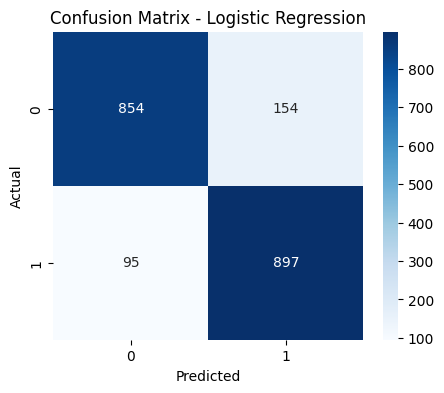

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = lr.predict(X_test_tfidf)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Model Performance Comparison

In [ ]:
results = {
    "Model": ["Logistic Regression", "Naive Bayes", "Decision Tree", "Random Forest"],
    "Accuracy": [0.8755, 0.841, 0.714, 0.832]
}

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy
0,Logistic Regression,0.8755
1,Naive Bayes,0.8410
2,Decision Tree,0.7140
3,Random Forest,0.8320


## Model Comparison & Insights

### Observations:
- Logistic Regression achieved the highest accuracy.
- Naive Bayes performed well with Bag of Words.
- Decision Tree underperformed due to overfitting.
- Random Forest improved performance compared to Decision Tree.

### Preprocessing Impact:
- Stopword removal improved clarity.
- Stemming reduced dimensionality.

### Feature Engineering:
- TF-IDF outperformed Bag of Words.

### Best Model:
Logistic Regression with TF-IDF.

### Trade-offs:
- TF-IDF is computationally expensive but accurate.
- BoW is faster but less informative.

## Final Result

Logistic Regression trained on TF-IDF features achieved the highest accuracy of 87.55%, outperforming all other models.

This indicates that TF-IDF effectively captures important textual patterns, and Logistic Regression is well-suited for high-dimensional text data.

Hence, Logistic Regression with TF-IDF is selected as the best model for this sentiment analysis task.

## Conclusion

In this project, we successfully built an end-to-end NLP pipeline for sentiment analysis. We applied preprocessing, feature engineering, and trained multiple ML models.

Logistic Regression with TF-IDF gave the best performance.

This project demonstrates how raw text can be transformed into meaningful insights using NLP and ML techniques.

### Note:
The dataset used in this project is the IMDb Dataset from Kaggle.
Due to size constraints, the dataset file is not uploaded to GitHub.

### Dataset Source:
https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews